# Étape 2 & 3 — Entraînement des modèles et tracking MLflow

Chargement du dataset préparé à l'Étape 1, puis entraînement de modèles de scoring
avec suivi des expérimentations via MLflow.

In [1]:
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

In [2]:
# On recharge le dataset propre de l'Étape 1 (instantané grâce au Parquet)
df = pd.read_parquet("../data/df_prepared.parquet")

# X = les variables explicatives ; y = la cible
# On retire TARGET (la réponse) et SK_ID_CURR (un simple identifiant, sans valeur prédictive)
X = df.drop(columns=["TARGET", "SK_ID_CURR"])
y = df["TARGET"]

# Filet 1 : neutraliser les inf issus des ratios satellites
X = X.replace([np.inf, -np.inf], np.nan)

# Filet 2 : forcer les colonnes object (min/max de booléens) en numérique
obj_cols = X.select_dtypes("object").columns
X[obj_cols] = X[obj_cols].apply(pd.to_numeric, errors="coerce")

# Filet 3 : assainir les noms de colonnes (LightGBM/XGBoost refusent les caractères spéciaux)
import re
X.columns = [re.sub(r"[^A-Za-z0-9_]+", "_", str(c)) for c in X.columns]

print("X :", X.shape,
      "| object:", len(X.select_dtypes('object').columns),
      "| inf:", int(np.isinf(X.select_dtypes('number')).values.sum()))
print("Répartition de y :", y.value_counts(normalize=True).round(3).to_dict())

X : (307511, 800) | object: 0 | inf: 0
Répartition de y : {0: 0.919, 1: 0.081}


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train :", X_train.shape, "| Test :", X_test.shape)
print("Taux de défaut — train :", round(y_train.mean(), 4), "| test :", round(y_test.mean(), 4))


Train : (246008, 800) | Test : (61503, 800)
Taux de défaut — train : 0.0807 | test : 0.0807


In [4]:
mlflow.set_tracking_uri("sqlite:///../mlflow.db")   # base à la racine du projet
mlflow.set_experiment("scoring_credit")

<Experiment: artifact_location='/Users/matthieu/dev/openclassrooms/projet6/notebooks/mlruns/1', creation_time=1783423574127, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783423574127, lifecycle_stage='active', name='scoring_credit', tags={}, trace_location=None, workspace='default'>

In [5]:
with mlflow.start_run(run_name="baseline_histgb"):
    params = {"max_iter": 200, "learning_rate": 0.1}
    model = HistGradientBoostingClassifier(**params, random_state=42)
    model.fit(X_train, y_train)

    # Prédictions sur le test
    proba = model.predict_proba(X_test)[:, 1]   # probabilité de défaut
    auc = roc_auc_score(y_test, proba)
    acc = accuracy_score(y_test, model.predict(X_test))

    # On enregistre TOUT dans MLflow
    mlflow.log_params(params)
    mlflow.log_metric("AUC", auc)
    mlflow.log_metric("accuracy", acc)
    mlflow.sklearn.log_model(model, artifact_path="model")

    print(f"AUC = {auc:.4f} | accuracy = {acc:.4f}")

2026/07/08 13:20:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/08 13:20:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


AUC = 0.7827 | accuracy = 0.9203


## Étape 3 — Modélisation et comparaison de plusieurs algorithmes

Objectif : entraîner plusieurs familles de modèles, les évaluer par **validation croisée
stratifiée**, et les comparer sur des métriques adaptées au déséquilibre (AUC, recall, F1)
et sur le **score métier** (coût = 10×FN + FP), afin de sélectionner le meilleur.

Rappels : classes déséquilibrées (~7,7 % de défauts) → on gère avec `class_weight`,
et on ne se fie pas à l'accuracy. Un FN (mauvais client accepté) coûte 10× un FP.

Pour itérer rapidement, la comparaison se fait sur un sous-échantillon de 50 000 clients ;
le modèle retenu sera ré-entraîné sur l'ensemble complet en Étape 4.

In [6]:
from sklearn.metrics import confusion_matrix

def cout_metier(y_true, y_pred):
    # confusion_matrix renvoie, dans l'ordre : TN, FP, FN, TP
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cout = 10 * fn + 1 * fp
    return cout

### 3.1 — Le score métier

Un faux négatif (mauvais client accepté → perte en capital) coûte 10× un faux positif (bon client refusé → manque à gagner). On définit un coût = 10×FN + FP : **plus il est bas, meilleur est le modèle**.

In [7]:
cout_metier(y_test, model.predict(X_test))

np.int64(47625)

### 3.2 — Évaluation par validation croisée stratifiée

On évalue chaque modèle avec `StratifiedKFold` (5 plis, proportions de classes préservées) via `cross_val_predict` : chaque client est prédit par un modèle qui ne l'a pas vu.
Beaucoup plus fiable qu'un simple découpage train/test. Comparaison sur 50 000 clients pour itérer vite.

In [8]:
X_cmp, _, y_cmp, _ = train_test_split(X, y, train_size=50000, stratify=y, random_state=42)
print("Échantillon de comparaison :", X_cmp.shape)

Échantillon de comparaison : (50000, 800)


In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluer_modele(model, nom, tags=None):
    with mlflow.start_run(run_name=nom):
        # Prédictions "hors échantillon" : chaque client est prédit par un modèle qui ne l'a jamais vu
        proba = cross_val_predict(model, X_cmp, y_cmp, cv=cv, method="predict_proba")[:, 1]
        preds = (proba >= 0.5).astype(int)

        metriques = {
            "AUC":         roc_auc_score(y_cmp, proba),
            "accuracy":    accuracy_score(y_cmp, preds),
            "recall":      recall_score(y_cmp, preds),
            "f1":          f1_score(y_cmp, preds),
            "cout_metier": cout_metier(y_cmp, preds),
        }
        mlflow.log_metrics(metriques)
        mlflow.set_tag("etape", "3-comparaison")
        if tags:
            mlflow.set_tags(tags)
        print(f"{nom} → AUC={metriques['AUC']:.4f} | recall={metriques['recall']:.4f} | coût={metriques['cout_metier']:.0f}")
        return metriques


### 3.3 — Entraînement et comparaison des modèles

On teste 3 familles : linéaire (Régression Logistique), forêt (Random Forest), et boosting (HistGradientBoosting, LightGBM, XGBoost). Le déséquilibre est géré via `class_weight="balanced"` (ou `scale_pos_weight` pour XGBoost). Chaque run est tracké dans MLflow.

In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier

evaluer_modele(
    HistGradientBoostingClassifier(random_state=42),
    "hgb_naif",
    tags={"model": "HistGradientBoosting", "desequilibre": "aucun"},
)

evaluer_modele(
    HistGradientBoostingClassifier(class_weight="balanced", random_state=42),
    "hgb_balanced",
    tags={"model": "HistGradientBoosting", "desequilibre": "class_weight"},
)

hgb_naif → AUC=0.7582 | recall=0.0233 | coût=39541
hgb_balanced → AUC=0.7594 | recall=0.6117 | coût=26410


{'AUC': 0.7593779116918233,
 'accuracy': 0.75386,
 'recall': 0.6117443012884044,
 'f1': 0.28634386778776455,
 'cout_metier': np.int64(26410)}

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Régression Logistique : imputation + standardisation + modèle, le tout dans une Pipeline
logreg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("clf",     LogisticRegression(max_iter=1000, class_weight="balanced")),
])
evaluer_modele(logreg, "logreg_balanced",
               tags={"model": "LogisticRegression", "desequilibre": "class_weight"})

# Random Forest : imputation + modèle (pas besoin de standardiser pour un arbre)
rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf",     RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                        n_jobs=-1, random_state=42)),
])
evaluer_modele(rf, "rf_balanced",
               tags={"model": "RandomForest", "desequilibre": "class_weight"})

logreg_balanced → AUC=0.7475 | recall=0.6620 | coût=26775
rf_balanced → AUC=0.7308 | recall=0.0273 | coût=39467


{'AUC': 0.7308458141585189,
 'accuracy': 0.91734,
 'recall': 0.027254707631318136,
 'f1': 0.0505398575694923,
 'cout_metier': np.int64(39467)}

In [12]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

evaluer_modele(
    LGBMClassifier(n_estimators=200, class_weight="balanced", random_state=42, verbose=-1),
    "lgbm_balanced",
    tags={"model": "LightGBM", "desequilibre": "class_weight"},
)

# XGBoost gère le déséquilibre via scale_pos_weight = nb_négatifs / nb_positifs (~11)
spw = (y == 0).sum() / (y == 1).sum()
evaluer_modele(
    XGBClassifier(n_estimators=200, scale_pos_weight=spw, tree_method="hist",
                  eval_metric="logloss", random_state=42),
    "xgb_balanced",
    tags={"model": "XGBoost", "desequilibre": "scale_pos_weight"},
)

lgbm_balanced → AUC=0.7490 | recall=0.4291 | coût=28928
xgb_balanced → AUC=0.7030 | recall=0.1903 | coût=35056


{'AUC': 0.7029990490467871,
 'accuracy': 0.88712,
 'recall': 0.19028741328047571,
 'f1': 0.2139275766016713,
 'cout_metier': np.int64(35056)}

### 3.4 — Comparatif final des modèles

In [13]:
# On interroge MLflow pour récupérer tous les runs de comparaison
comparatif = mlflow.search_runs(
    experiment_names=["scoring_credit"],
    filter_string="tags.etape = '3-comparaison'",
)
comparatif = (
    comparatif[["tags.mlflow.runName", "metrics.AUC", "metrics.recall",
                "metrics.f1", "metrics.cout_metier"]]
    .rename(columns=lambda c: c.replace("metrics.", "").replace("tags.mlflow.runName", "modele"))
    .sort_values("cout_metier")
    .drop_duplicates("modele")        # 1 ligne par modèle (ignore les runs dupliqués)
    .reset_index(drop=True)
)
comparatif

,modele,AUC,recall,f1,cout_metier
0,hgb_balanced,0.759378,0.611744,0.286344,26410.0
1,logreg_balanced,0.747460,0.662042,0.269314,26775.0
2,lgbm_balanced,0.749013,0.429138,0.297186,28928.0
3,xgb_balanced,0.702999,0.190287,0.213928,35056.0
4,rf_balanced,0.730846,0.027255,0.050540,39467.0
5,hgb_naif,0.758185,0.023290,0.044225,39541.0


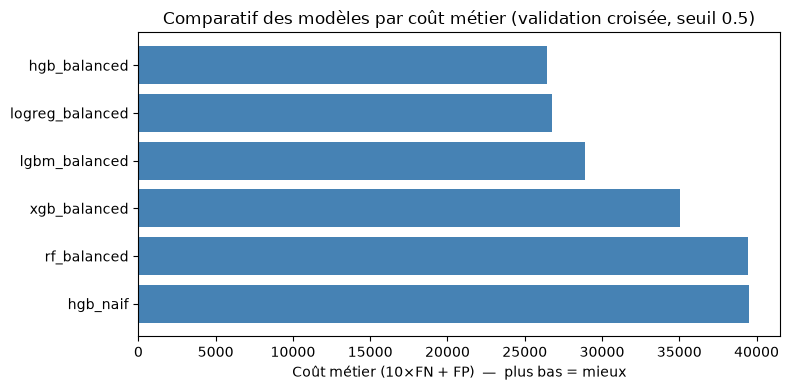

In [14]:
plt.figure(figsize=(8, 4))
plt.barh(comparatif["modele"], comparatif["cout_metier"], color="steelblue")
plt.gca().invert_yaxis()   # meilleur (coût le plus bas) en haut
plt.xlabel("Coût métier (10×FN + FP)  —  plus bas = mieux")
plt.title("Comparatif des modèles par coût métier (validation croisée, seuil 0.5)")
plt.tight_layout()
plt.show()

### Bilan de l'Étape 3

Six modèles comparés par validation croisée stratifiée (5 plis, 50 000 clients), avec gestion du déséquilibre. **Modèle retenu : `hgb_balanced`** (HistGradientBoosting +
`class_weight="balanced"`), meilleur à la fois sur le **coût métier** (26 410) et sur l'**AUC** (0.759).

- La gestion du déséquilibre est décisive : le modèle naïf (recall 2 %) est inexploitable.
- LightGBM / XGBoost sont ici **non optimisés** → leur fort potentiel sera exploité à l'Étape 4.
- Tous les scores sont au **seuil 0.5**, non optimal → l'Étape 4 optimisera ce seuil pour réduire encore le coût métier.

## Étape 4 — Optimisation du seuil et des hyperparamètres

### 4.1 — Optimisation du seuil de décision

Le seuil par défaut (0.5) n'est pas optimal vu l'asymétrie des coûts (FN = 10× FP).
On utilise un modèle aux probabilités calibrées (sans class_weight) et on cherche le seuil
qui minimise le coût métier, en traçant la courbe coût = f(seuil).

In [15]:
# Probabilités hors-échantillon d'un modèle "brut" (probabilités calibrées)
model_hgb = HistGradientBoostingClassifier(random_state=42)
proba_oof = cross_val_predict(model_hgb, X_cmp, y_cmp, cv=cv, method="predict_proba")[:, 1]

# Coût métier pour chaque seuil de 0.02 à 0.60
seuils = np.arange(0.02, 0.60, 0.01)
couts = [cout_metier(y_cmp, (proba_oof >= s).astype(int)) for s in seuils]

seuil_optimal = seuils[int(np.argmin(couts))]
cout_optimal = min(couts)
print(f"Seuil optimal : {seuil_optimal:.2f} → coût {cout_optimal:.0f}")
print(f"(comparaison — seuil 0.50 → coût {cout_metier(y_cmp, (proba_oof>=0.5).astype(int)):.0f})")

Seuil optimal : 0.09 → coût 26288
(comparaison — seuil 0.50 → coût 39541)


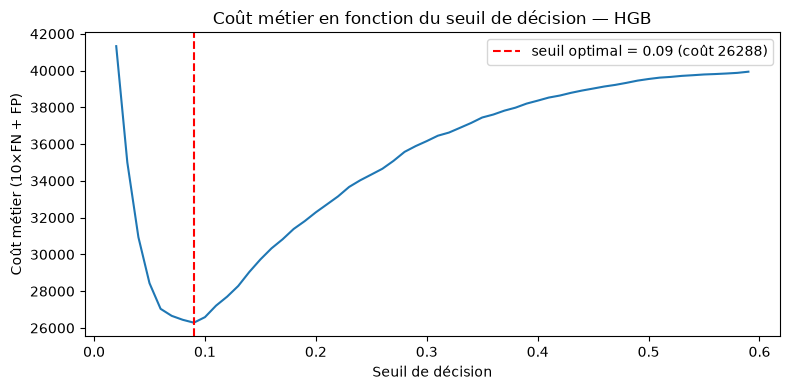

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(seuils, couts)
plt.axvline(seuil_optimal, color="red", linestyle="--",
            label=f"seuil optimal = {seuil_optimal:.2f} (coût {cout_optimal:.0f})")
plt.xlabel("Seuil de décision")
plt.ylabel("Coût métier (10×FN + FP)")
plt.title("Coût métier en fonction du seuil de décision — HGB")
plt.legend(); plt.tight_layout(); plt.show()

### 4.2 — Optimisation des hyperparamètres (GridSearchCV)

Pour chaque modèle, on cherche les meilleurs hyperparamètres par validation croisée
(jugés sur l'AUC), puis on applique la technique du seuil optimal pour obtenir le coût métier.
Chaque modèle optimisé est tracké dans MLflow.

In [17]:
from sklearn.model_selection import GridSearchCV

def optimiser_modele(estimateur, grille, nom):
    with mlflow.start_run(run_name=nom):
        # 1) Recherche des meilleurs hyperparamètres (jugée sur l'AUC)
        gs = GridSearchCV(estimateur, grille, scoring="roc_auc",
                          cv=StratifiedKFold(3, shuffle=True, random_state=42), n_jobs=-1)
        gs.fit(X_cmp, y_cmp)
        best = gs.best_estimator_

        # 2) Probabilités hors-échantillon du modèle optimisé
        proba = cross_val_predict(best, X_cmp, y_cmp, cv=cv, method="predict_proba")[:, 1]

        # 3) Seuil qui minimise le coût métier
        seuils = np.arange(0.02, 0.60, 0.01)
        couts = [cout_metier(y_cmp, (proba >= s).astype(int)) for s in seuils]
        i = int(np.argmin(couts))
        seuil_opt, cout_opt = seuils[i], couts[i]

        # 4) Traçage MLflow
        mlflow.log_params(gs.best_params_)
        mlflow.log_metric("AUC", roc_auc_score(y_cmp, proba))
        mlflow.log_metric("seuil_optimal", seuil_opt)
        mlflow.log_metric("cout_metier_optimal", cout_opt)
        mlflow.set_tag("etape", "4-optimisation")
        print(f"{nom} → AUC={roc_auc_score(y_cmp, proba):.4f} | seuil*={seuil_opt:.2f} | coût*={cout_opt:.0f}")
        print(f"   meilleurs params : {gs.best_params_}")
        return {"nom": nom, "estimateur": best, "seuil": seuil_opt, "cout": cout_opt}


In [18]:
from sklearn.ensemble import HistGradientBoostingClassifier
from lightgbm import LGBMClassifier

res_hgb = optimiser_modele(
    HistGradientBoostingClassifier(random_state=42),
    {"learning_rate": [0.05, 0.1], "max_leaf_nodes": [31, 63], "max_iter": [300]},
    "hgb_optimise",
)
res_lgbm = optimiser_modele(
    LGBMClassifier(random_state=42, verbose=-1),
    {"learning_rate": [0.03, 0.05], "num_leaves": [31, 63], "n_estimators": [400]},
    "lgbm_optimise",
)


hgb_optimise → AUC=0.7619 | seuil*=0.08 | coût*=26148
   meilleurs params : {'learning_rate': 0.05, 'max_iter': 300, 'max_leaf_nodes': 31}
lgbm_optimise → AUC=0.7658 | seuil*=0.07 | coût*=25982
   meilleurs params : {'learning_rate': 0.03, 'n_estimators': 400, 'num_leaves': 31}


### 4.3 — Modèle final : LightGBM optimisé sur l'ensemble complet

On entraîne le modèle retenu (LightGBM optimisé) sur tout l'ensemble d'entraînement.
Le seuil optimal est dérivé par validation croisée sur l'entraînement (sans fuite),
puis le modèle est évalué sur le jeu de test (clients jamais vus).

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

modele_final = LGBMClassifier(learning_rate=0.03, n_estimators=400, num_leaves=31,
                              random_state=42, verbose=-1)

# Seuil optimal dérivé proprement par validation croisée sur l'entraînement (sans fuite)
proba_oof = cross_val_predict(modele_final, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
seuils = np.arange(0.02, 0.60, 0.01)
SEUIL_FINAL = float(seuils[int(np.argmin(
    [cout_metier(y_train, (proba_oof >= s).astype(int)) for s in seuils]))])
print("Seuil final :", round(SEUIL_FINAL, 2))

# Entraînement final + évaluation sur le test
modele_final.fit(X_train, y_train)
proba_test = modele_final.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= SEUIL_FINAL).astype(int)

print("AUC test         :", round(roc_auc_score(y_test, proba_test), 4))
print("Coût métier test :", cout_metier(y_test, pred_test))
print("Recall test      :", round(recall_score(y_test, pred_test), 3))

Seuil final : 0.08
AUC test         : 0.7874
Coût métier test : 29979
Recall test      : 0.709


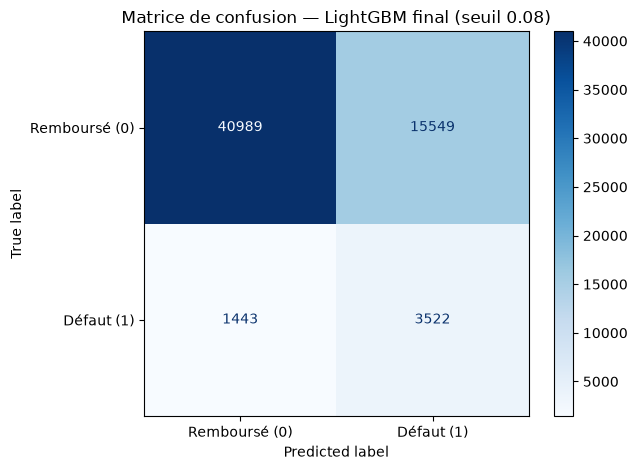

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_test, display_labels=["Remboursé (0)", "Défaut (1)"], cmap="Blues")
plt.title(f"Matrice de confusion — LightGBM final (seuil {SEUIL_FINAL:.2f})")
plt.tight_layout(); plt.show()

### 4.4 — Enregistrement du modèle dans le Model Registry

Le modèle final est enregistré dans le Model Registry MLflow (versionné, prêt pour le
déploiement) avec ses métriques de test et son seuil de décision.

In [22]:
import mlflow.lightgbm

with mlflow.start_run(run_name="modele_final_lgbm"):
    mlflow.log_params({"learning_rate": 0.03, "n_estimators": 400, "num_leaves": 31})
    mlflow.log_metric("seuil_final", SEUIL_FINAL)
    mlflow.log_metric("AUC_test", roc_auc_score(y_test, proba_test))
    mlflow.log_metric("cout_metier_test", cout_metier(y_test, pred_test))
    mlflow.set_tag("etape", "4-modele-final")
    mlflow.lightgbm.log_model(            # <-- saveur LightGBM (au lieu de mlflow.sklearn)
        modele_final,
        name="model",
        registered_model_name="scoring_credit_lgbm",
    )
print("Modèle enregistré dans le Model Registry : 'scoring_credit_lgbm'")

2026/07/08 14:10:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Modèle enregistré dans le Model Registry : 'scoring_credit_lgbm'


Successfully registered model 'scoring_credit_lgbm'.
Created version '1' of model 'scoring_credit_lgbm'.
